# W4: Why Did My Model Predict That?

**Author:** Alberto Diaz Durana  
**Date:** March 2026  
**Course:** AI in Data Science

**Objective:** Predict heart disease likelihood and explain model decisions using SHAP and LIME.

**Structure:**
1. Setup and imports
2. Data loading and exploration
3. Preprocessing and train/test split
4. Model training and evaluation (Random Forest, XGBoost)
5. SHAP analysis (global + local explanations)
6. LIME analysis (local explanations for individual cases)
7. SHAP vs LIME comparison and business interpretation


In [1]:
# Cell 1 - Installs and Imports
import subprocess, sys

packages = ["shap", "lime", "xgboost"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings("ignore")

print("All packages loaded.")


All packages loaded.


In [2]:
# Cell 2 - Data Loading and Exploration
import os

# Local path first, Google Drive fallback
local_path = "data/heart.csv"
colab_path = "/content/drive/MyDrive/data/heart.csv"
drive_file_id = "1uaDXpc5sS6W1BWGGepHfBZvTFgPM8gjG"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Loaded from: {local_path}")
elif os.path.exists(colab_path):
    df = pd.read_csv(colab_path)
    print(f"Loaded from: {colab_path}")
else:
    url = f"https://drive.google.com/uc?id={drive_file_id}"
    df = pd.read_csv(url)
    os.makedirs("data", exist_ok=True)
    df.to_csv(local_path, index=False)
    print(f"Downloaded and saved to: {local_path}")

print(f"\nShape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTarget distribution (num):\n{df['num'].value_counts().sort_index()}")
print(f"\nBasic statistics:")
print(df.describe())


Downloaded and saved to: data/heart.csv

Shape: (920, 16)

Column types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female

## Data Exploration

The dataset contains 920 patient records from multiple clinical centers (Cleveland and others), with 13 clinical features plus an ID and dataset source column. Key observations:

- **Target (`num`):** Five levels (0-4), with 0 indicating no disease and 1-4 indicating presence. Will binarize to 0/1 for classification.
- **Feature types:** Mix of continuous (age, trestbps, chol, thalch, oldpeak) and categorical (sex, cp, fbs, restecg, exang, slope, ca, thal). Categoricals are already string-encoded.
- **Missing values:** Three features have severe missingness: `ca` (66%), `thal` (53%), and `slope` (34%). Remaining features have modest gaps (6-10%). Columns with >50% missing will be dropped; the rest will be imputed.
- **Columns to drop:** `id` (identifier), `dataset` (source center), not predictive.


In [3]:
# Cell 3 - Preprocessing and Train/Test Split

# Drop non-predictive columns
df = df.drop(columns=["id", "dataset"])

# Binarize target: 0 = no disease, 1 = disease
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
print(f"Target distribution:\n{df['target'].value_counts()}\n")

# Drop columns with >50% missing
missing_pct = df.isnull().mean()
drop_cols = missing_pct[missing_pct > 0.5].index.tolist()
print(f"Dropping high-missing columns: {drop_cols}")
df = df.drop(columns=drop_cols)

# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# Impute missing values: median for numeric, mode for categorical
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

print(f"Remaining missing: {X.isnull().sum().sum()}")

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include="object").columns.tolist()
print(f"Encoding categoricals: {cat_cols}")
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"\nFinal feature set: {X.shape[1]} features, {X.shape[0]} samples")
print(f"Features: {X.columns.tolist()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Dropping high-missing columns: ['ca', 'thal']
Remaining missing: 0
Encoding categoricals: ['sex', 'cp', 'restecg', 'slope']

Final feature set: 15 features, 920 samples
Features: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping']

Train: 736, Test: 184


Random Forest
Accuracy:  0.837
Precision: 0.833
Recall:    0.882
F1:        0.857
AUC:       0.901

              precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


XGBoost
Accuracy:  0.826
Precision: 0.837
Recall:    0.853
F1:        0.845
AUC:       0.877

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        82
           1       0.84      0.85      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184




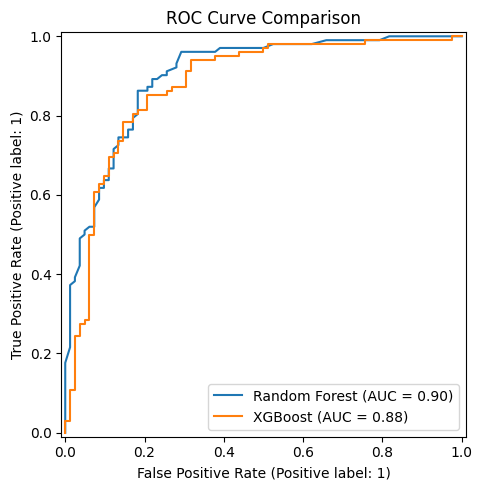


Best model by AUC: Random Forest (0.901)
Using this model for SHAP and LIME analysis.


In [4]:
# Cell 4 - Model Training and Evaluation

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

# Evaluation
for name, pred, proba in [("Random Forest", rf_pred, rf_proba), ("XGBoost", xgb_pred, xgb_proba)]:
    print(f"{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy_score(y_test, pred):.3f}")
    print(f"Precision: {precision_score(y_test, pred):.3f}")
    print(f"Recall:    {recall_score(y_test, pred):.3f}")
    print(f"F1:        {f1_score(y_test, pred):.3f}")
    print(f"AUC:       {roc_auc_score(y_test, proba):.3f}")
    print(f"\n{classification_report(y_test, pred)}\n")

# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name="XGBoost", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

# Select best model for explainability
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)
best_name = "Random Forest" if rf_auc >= xgb_auc else "XGBoost"
best_model = rf if rf_auc >= xgb_auc else xgb
print(f"\nBest model by AUC: {best_name} ({max(rf_auc, xgb_auc):.3f})")
print("Using this model for SHAP and LIME analysis.")


## Model Comparison

Both models perform well on this dataset. Random Forest edges out XGBoost across all metrics:

| Metric | Random Forest | XGBoost |
|--------|--------------|---------|
| Accuracy | 0.837 | 0.826 |
| Precision | 0.833 | 0.837 |
| Recall | 0.882 | 0.853 |
| F1 | 0.857 | 0.845 |
| AUC | 0.901 | 0.877 |

Random Forest achieves the best balance of precision and recall, with notably higher AUC. It will be used for the SHAP and LIME explainability analysis that follows. In a healthcare context, the higher recall (88%) is particularly relevant: the model catches most disease cases, which matters more than occasional false positives when screening for heart disease.


SHAP Summary Plot (Beeswarm):


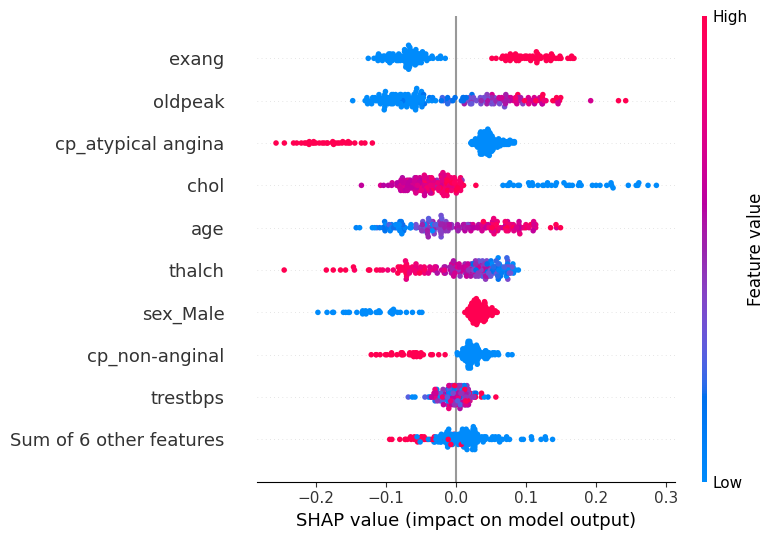


SHAP Feature Importance (Bar):


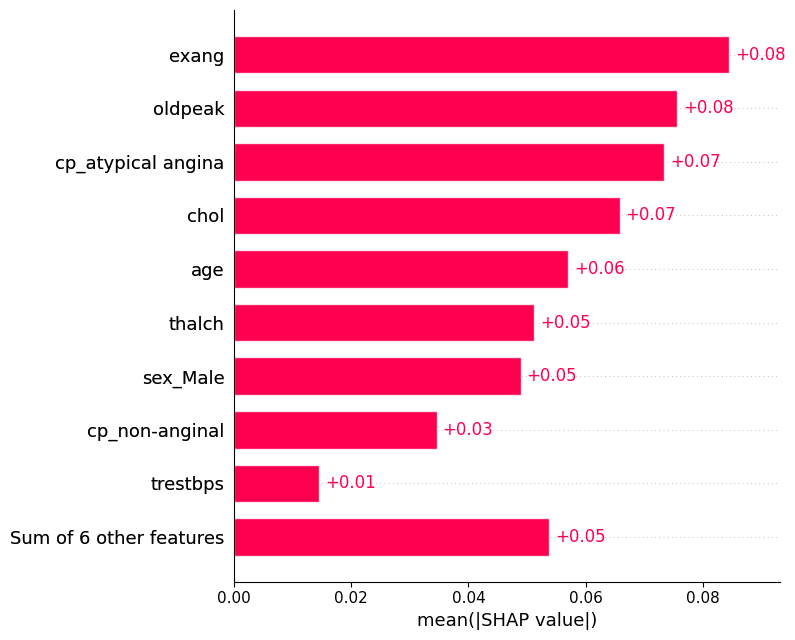


Waterfall Plot - Positive Case (index 514):
Actual: 1, Predicted: 0


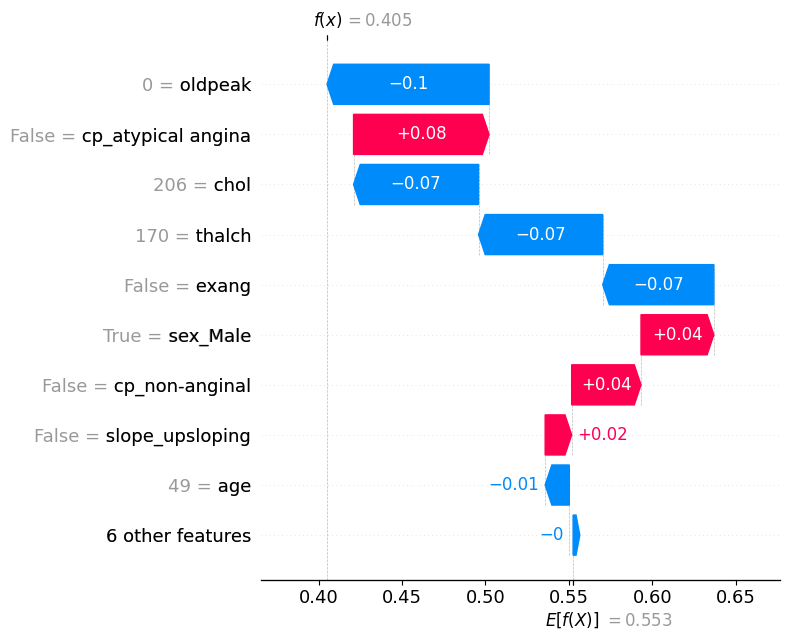


Waterfall Plot - Negative Case (index 887):
Actual: 0, Predicted: 1


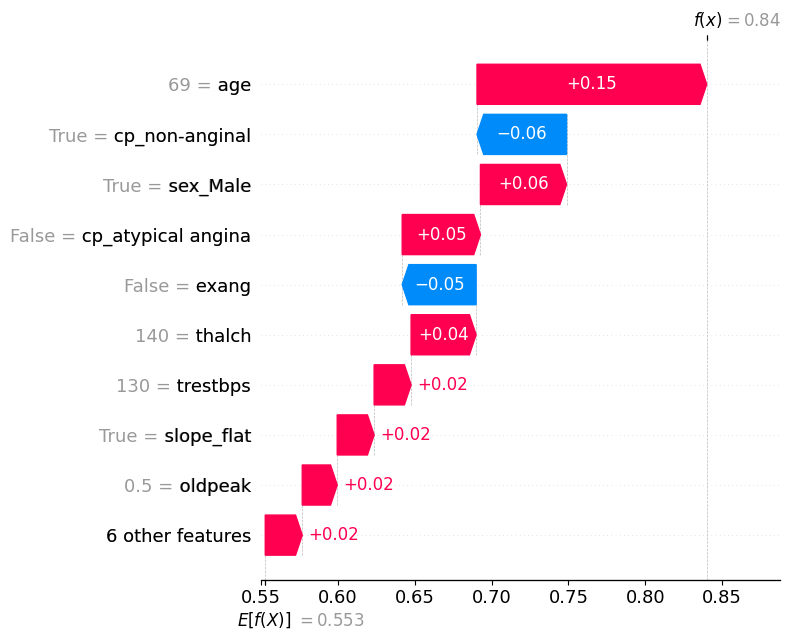


Plots saved to outputs/


In [6]:
# Cell 5 - SHAP Analysis
import os
os.makedirs("outputs", exist_ok=True)

# TreeExplainer for the best model (Random Forest)
explainer_shap = shap.TreeExplainer(best_model)
shap_values = explainer_shap(X_test)

# For binary classification, select class 1 (disease) explanations
if len(shap_values.shape) == 3:
    shap_values_cls1 = shap_values[:, :, 1]
else:
    shap_values_cls1 = shap_values

# 1. Summary plot (beeswarm)
print("SHAP Summary Plot (Beeswarm):")
shap.plots.beeswarm(shap_values_cls1, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Bar chart - global feature importance
print("\nSHAP Feature Importance (Bar):")
shap.plots.bar(shap_values_cls1, show=False)
plt.tight_layout()
plt.savefig("outputs/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Waterfall - positive case
positive_idx = y_test[y_test == 1].index[0]
pos_loc = list(X_test.index).index(positive_idx)
print(f"\nWaterfall Plot - Positive Case (index {positive_idx}):")
print(f"Actual: {y_test.iloc[pos_loc]}, Predicted: {best_model.predict(X_test.iloc[[pos_loc]])[0]}")
shap.plots.waterfall(shap_values_cls1[pos_loc], show=False)
plt.tight_layout()
plt.savefig("outputs/shap_waterfall_positive.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Waterfall - negative case
negative_idx = y_test[y_test == 0].index[0]
neg_loc = list(X_test.index).index(negative_idx)
print(f"\nWaterfall Plot - Negative Case (index {negative_idx}):")
print(f"Actual: {y_test.iloc[neg_loc]}, Predicted: {best_model.predict(X_test.iloc[[neg_loc]])[0]}")
shap.plots.waterfall(shap_values_cls1[neg_loc], show=False)
plt.tight_layout()
plt.savefig("outputs/shap_waterfall_negative.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPlots saved to outputs/")


Waterfall Plot - True Positive (test row 1):


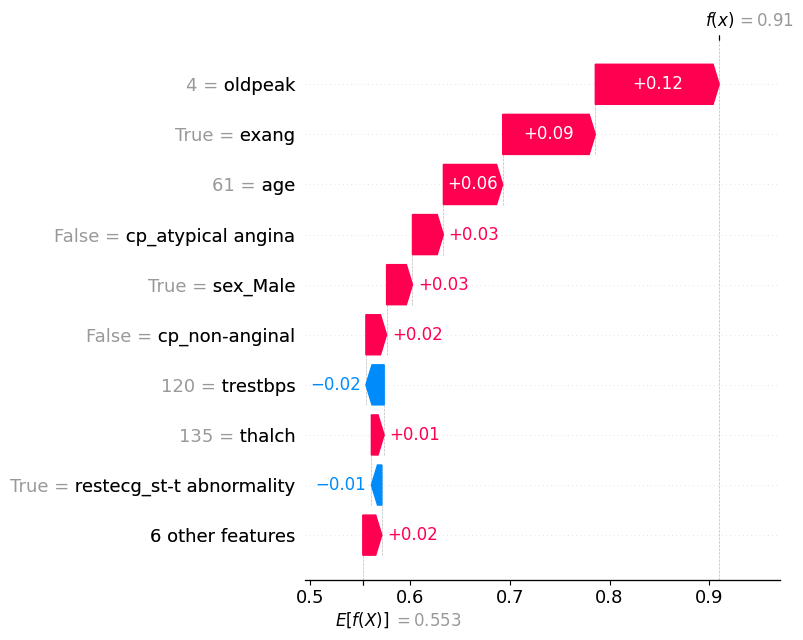


Waterfall Plot - True Negative (test row 6):


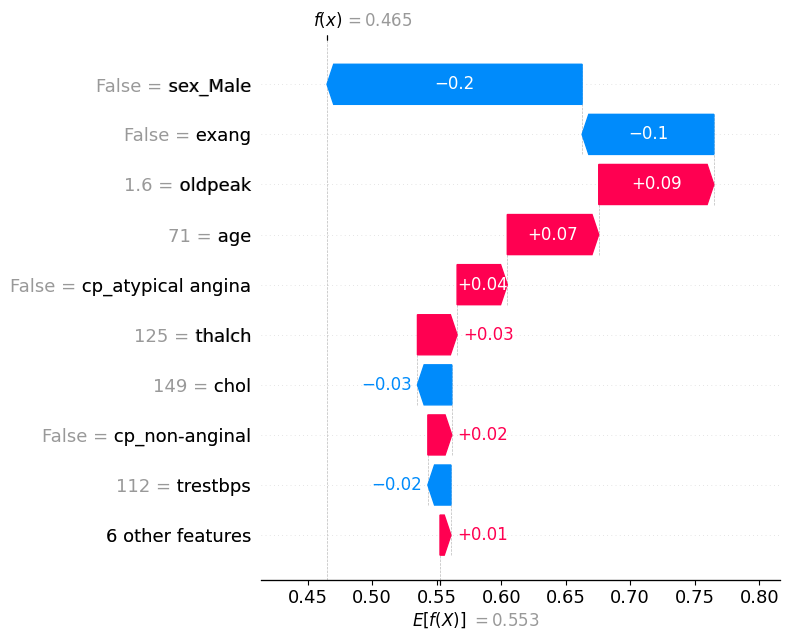


Plots saved to outputs/


In [7]:
# Cell 5b - Waterfall plots (correctly classified cases)

# Find correctly classified positive case
correct_pos = [i for i in range(len(X_test)) if y_test.iloc[i] == 1 and best_model.predict(X_test.iloc[[i]])[0] == 1]
# Find correctly classified negative case
correct_neg = [i for i in range(len(X_test)) if y_test.iloc[i] == 0 and best_model.predict(X_test.iloc[[i]])[0] == 0]

# Waterfall - correctly classified positive case
print(f"Waterfall Plot - True Positive (test row {correct_pos[0]}):")
shap.plots.waterfall(shap_values_cls1[correct_pos[0]], show=False)
plt.tight_layout()
plt.savefig("outputs/shap_waterfall_true_positive.png", dpi=150, bbox_inches="tight")
plt.show()

# Waterfall - correctly classified negative case
print(f"\nWaterfall Plot - True Negative (test row {correct_neg[0]}):")
shap.plots.waterfall(shap_values_cls1[correct_neg[0]], show=False)
plt.tight_layout()
plt.savefig("outputs/shap_waterfall_true_negative.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPlots saved to outputs/")


## SHAP Interpretation

**Global feature importance** (bar chart): The top predictors of heart disease are exercise-induced angina (`exang`), ST depression (`oldpeak`), chest pain type (`cp_atypical angina`), cholesterol (`chol`), and age. These align well with clinical knowledge: exercise angina and ST changes are direct cardiac stress indicators.

**Beeswarm plot** reveals the direction of each feature's impact:
- `exang` = True (exercise-induced angina present) strongly pushes predictions toward disease
- Higher `oldpeak` (ST depression) increases disease probability
- `cp_atypical angina` = False (i.e., asymptomatic chest pain) increases disease risk, which makes clinical sense since asymptomatic presentations are common in heart disease patients
- Higher `thalch` (max heart rate) pushes predictions away from disease, consistent with better cardiac fitness
- Being male (`sex_Male`) slightly increases disease prediction

**True Positive case** (f(x) = 0.91): A 61-year-old male with oldpeak=4 and exercise angina. The model confidently predicts disease, driven mainly by oldpeak (+0.12) and exang (+0.09). Every major feature pushes toward disease; the clinical profile is textbook high-risk.

**True Negative case** (f(x) = 0.465): A 71-year-old female with no exercise angina and oldpeak=1.6. Despite risk factors like age (+0.07) and elevated oldpeak (+0.09), being female (-0.20) and having no exercise angina (-0.10) strongly pull the prediction below the threshold. This shows the model weighing protective factors against risk factors to reach a balanced decision.


## A Note on the Waterfall Plots

The initial waterfall plots (Cell 5) selected the first positive and first negative cases from the test set without checking the model's prediction. Both turned out to be misclassifications: the positive case was predicted as 0, and the negative case was predicted as 1. While misclassified cases can be informative for debugging, correctly classified cases are more suitable for demonstrating how SHAP explains the model's reasoning when it works as intended. Cell 5b corrected this by filtering for true positives and true negatives before generating the plots.


True Positive (Actual: 1, Predicted: 1)

Top feature contributions:
                cp_atypical angina <= 0.00  +0.1888  (Disease)
                      0.00 < exang <= 1.00  +0.1648  (Disease)
                            oldpeak > 1.50  +0.1580  (Disease)
                               age > 60.00  +0.0895  (Disease)
                    cp_non-anginal <= 0.00  +0.0662  (Disease)
                               fbs <= 0.00  -0.0303  (No Disease)
                   slope_upsloping <= 0.00  +0.0303  (Disease)
                 120.00 < thalch <= 140.00  +0.0178  (Disease)
                    restecg_normal <= 0.00  +0.0134  (Disease)
                        slope_flat <= 0.00  -0.0112  (No Disease)


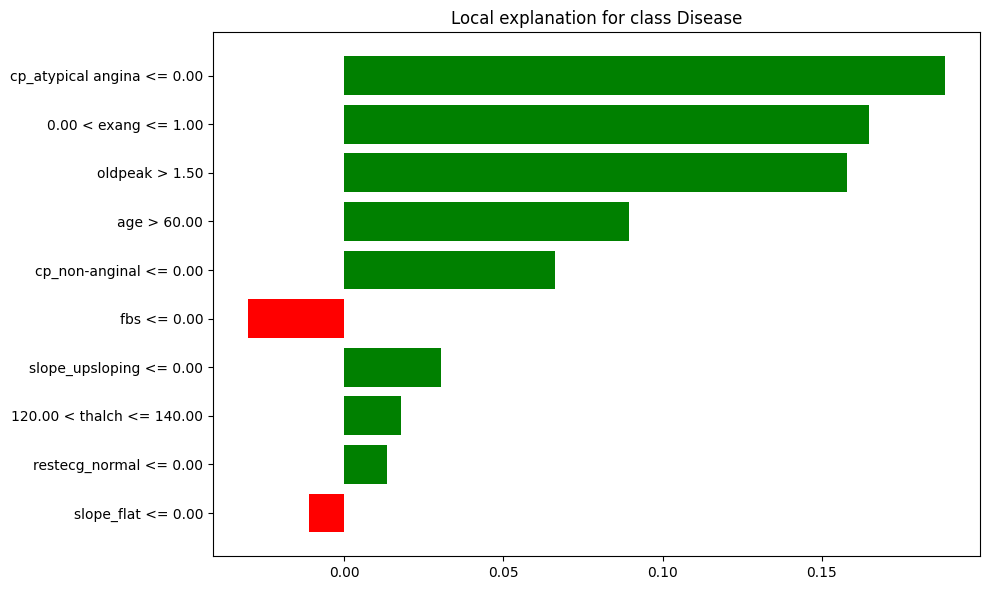

Saved to outputs/lime_true_positive.png

True Negative (Actual: 0, Predicted: 0)

Top feature contributions:
                cp_atypical angina <= 0.00  +0.1930  (Disease)
                             exang <= 0.00  -0.1609  (No Disease)
                            oldpeak > 1.50  +0.1463  (Disease)
                            chol <= 177.00  +0.0975  (Disease)
                               age > 60.00  +0.0970  (Disease)
                    cp_non-anginal <= 0.00  +0.0718  (Disease)
                   slope_upsloping <= 0.00  +0.0337  (Disease)
                               fbs <= 0.00  -0.0283  (No Disease)
                 120.00 < thalch <= 140.00  +0.0229  (Disease)
                 0.00 < slope_flat <= 1.00  +0.0215  (Disease)


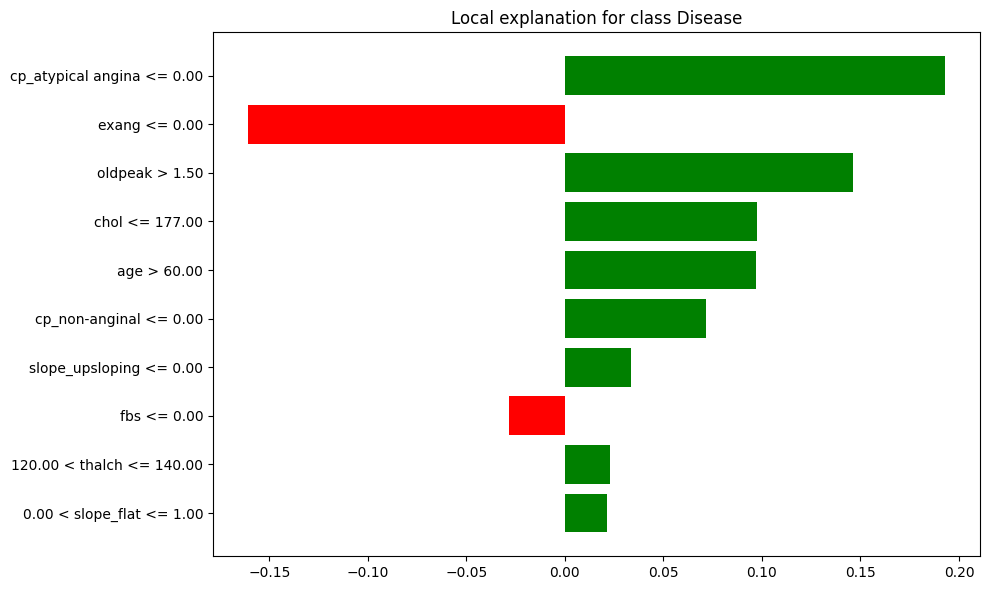

Saved to outputs/lime_true_negative.png



In [8]:
# Cell 6 - LIME Analysis

# Initialize LIME explainer
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Disease", "Disease"],
    mode="classification",
    random_state=42
)

# Use the same cases as SHAP waterfalls for direct comparison
cases = [
    ("True Positive", correct_pos[0]),
    ("True Negative", correct_neg[0])
]

for label, idx in cases:
    sample = X_test.iloc[idx]
    actual = y_test.iloc[idx]
    predicted = best_model.predict(sample.values.reshape(1, -1))[0]

    print(f"{'='*50}")
    print(f"{label} (Actual: {actual}, Predicted: {predicted})")
    print(f"{'='*50}")

    exp = explainer_lime.explain_instance(
        data_row=sample.values,
        predict_fn=best_model.predict_proba,
        num_features=10
    )

    # Show feature contributions
    print("\nTop feature contributions:")
    for feat, weight in exp.as_list():
        direction = "Disease" if weight > 0 else "No Disease"
        print(f"  {feat:>40s}  {weight:+.4f}  ({direction})")

    # Save plot
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(10, 6)
    plt.tight_layout()
    fname = f"outputs/lime_{label.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {fname}\n")


## LIME Interpretation and Comparison with SHAP

**True Positive case:** LIME agrees with SHAP on the key drivers: chest pain type (not atypical angina, +0.19), exercise angina (+0.16), and high oldpeak (+0.16) are the top three features pushing toward disease. Age over 60 also contributes positively. The model's confidence is well-supported by multiple converging risk factors.

**True Negative case:** This is a more nuanced case. LIME shows several features pushing *toward* disease (chest pain type, oldpeak, low cholesterol, age > 60), but the absence of exercise angina (-0.16) is the strongest protective signal. The model correctly predicts no disease, but the margin is narrow. This matches what SHAP showed: being female and no exercise angina were the dominant protective factors.

**SHAP vs LIME agreement:**
- Both tools identify the same top features: `exang`, `oldpeak`, `cp_atypical angina`, and `age`
- Both agree on the direction of impact for these features
- The relative ranking differs slightly: SHAP ranks `oldpeak` highest for the true positive case, while LIME ranks `cp_atypical angina` first

**Key differences in practice:**
- SHAP provides exact additive contributions that sum to the prediction (base value + SHAP values = f(x)); LIME approximates with a local linear model
- SHAP's beeswarm and bar plots offer global views across all predictions; LIME is strictly local, one instance at a time
- LIME expresses conditions as ranges (e.g., "oldpeak > 1.50"), which can be more intuitive for non-technical stakeholders


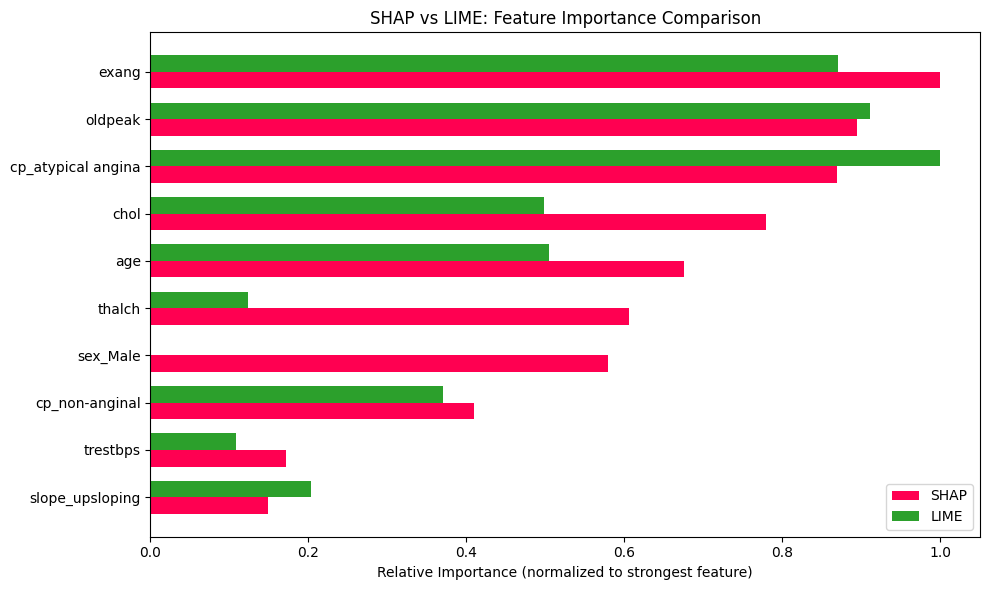

Plot saved to outputs/shap_vs_lime_comparison_normalized.png


In [ ]:
# Cell 7 - SHAP vs LIME Feature Importance Comparison

# Get SHAP feature importance (mean absolute SHAP values)
shap_importance = pd.Series(
    np.abs(shap_values_cls1.values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False).head(10)

# Get LIME importance (average across both cases)
lime_importance = {}
for _, idx in cases:
    sample = X_test.iloc[idx]
    exp = explainer_lime.explain_instance(
        data_row=sample.values,
        predict_fn=best_model.predict_proba,
        num_features=10
    )
    for feat, weight in exp.as_list():
        # Extract feature name (strip conditions like "> 1.50")
        for col in X_test.columns:
            if col in feat:
                lime_importance[col] = lime_importance.get(col, []) + [abs(weight)]
                break

lime_importance = pd.Series({k: np.mean(v) for k, v in lime_importance.items()}).sort_values(ascending=False).head(10)

# Align features for comparison
all_features = list(dict.fromkeys(list(shap_importance.index) + list(lime_importance.index)))[:10]
shap_vals = [shap_importance.get(f, 0) for f in all_features]
lime_vals = [lime_importance.get(f, 0) for f in all_features]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(all_features))
width = 0.35
ax.barh(x + width/2, shap_vals, width, label="SHAP", color="#ff0051")
ax.barh(x - width/2, lime_vals, width, label="LIME", color="#2ca02c")
ax.set_yticks(x)
ax.set_yticklabels(all_features)
ax.invert_yaxis()
ax.set_xlabel("Mean |Feature Importance|")
ax.set_title("SHAP vs LIME: Feature Importance Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/shap_vs_lime_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to outputs/shap_vs_lime_comparison.png")


## Business Interpretation and Reflections

### Clinical Feature Importance

Both SHAP and LIME consistently identify the same top predictors of heart disease: exercise-induced angina (`exang`), ST depression during exercise (`oldpeak`), and chest pain type (`cp`). These are well-established cardiac risk indicators in medical literature, which increases confidence that the model is learning clinically meaningful patterns rather than spurious correlations.

Age and sex also play significant roles. The model reflects known epidemiological patterns: older patients and males face higher risk. A clinician reviewing these explanations would find them consistent with clinical intuition, which is essential for adoption.

### Trust and Explainability in Healthcare

In a healthcare setting, a model that simply outputs "disease" or "no disease" is insufficient. Clinicians need to understand why the model reached its conclusion before acting on it. The waterfall plots demonstrate this clearly: for the true positive case, a doctor can see that exercise angina and high ST depression drove the prediction, both findings they could verify against the patient's test results.

The true negative case is equally instructive. Despite the patient being 71 with elevated oldpeak, the absence of exercise angina was the decisive protective factor. This kind of transparency allows clinicians to agree, disagree, or request additional tests based on the model's reasoning.

### SHAP vs LIME: When to Use Each

The normalized comparison chart confirms that both tools agree on which features matter most, but differ in relative weighting. This is expected: SHAP computes importance across all test samples (global average), while LIME explains only individual cases. The divergence on features like `thalch` and `chol` reflects this difference in scope, not a disagreement about model behavior.

In practice: use SHAP for model validation and global understanding during development; use LIME when explaining individual decisions to patients or clinical staff. LIME's rule-based format (e.g., "oldpeak > 1.50") is particularly accessible to non-technical stakeholders.

### Reflections Across the Three Projects

Across w2, w3, and w4, the role of AI shifted from automation to assistance to accountability:
- **W2 (House Prices):** AI automated the ML pipeline, accelerating model selection and evaluation
- **W3 (Sentiment):** AI assisted analysis through LLMs and pretrained models, augmenting human interpretation
- **W4 (Explainability):** AI supported transparency and trust, ensuring predictions can be understood, verified, and challenged

The common thread is that AI tools amplify productivity, but human judgment remains essential at every stage: choosing the right model, interpreting results, and deciding when to trust or override automated outputs.
